In [1]:
import helpers
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1.0,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2.0,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3.0,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4.0,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5.0,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


(<Figure size 500x450 with 2 Axes>,
 <Axes: title={'center': 'Streamfunction'}, xlabel='X', ylabel='Y'>)

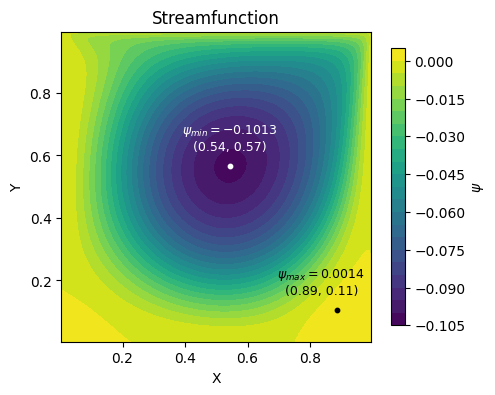

In [ ]:


CavityCase = helpers.CavityCase
case = CavityCase(4)
case.animate(step=4)
# case_1.ds.U.sel(y=0.5, method='nearest')
# case_1 = CavityCase(7)
# # case_1.plot()
# case_1.snap_times, case_1.snapshots
# # case_1.animate(saveFig=True)
# case_1.v_horizontal_slice()
# psi = case.psi
# print(psi.min(), psi.max())
# plt.contourf(case.X, case.Y, psi, levels=20)
# plt.colorbar()
# plt.show()
# case.vortex_strengths
case.plot_psi()

In [5]:
importlib.reload(helpers)
CaseManager = helpers.CaseManager
manager = CaseManager([1,2,3,4,5])
# uds_primary = manager.collect_vortex_strengths()

manager.collect_vortex_strengths()
manager2 = CaseManager([6,7,8,9])

In [14]:
manager3 = CaseManager([26,27,28,29])

In [23]:
psi_min3, psi_max3 = manager3.collect_vortex_strengths()
psi_min, psi_max = manager.collect_vortex_strengths()
psi_min3['psi']- psi_min3['psi']
psi_max3['psi']- psi_max3['psi']
psi_min3,psi_min


(    vortex         x         y       psi  case      RE  scheme    N
 0  primary  0.656250  0.593750 -0.060838    26  1000.0  simple   16
 1  primary  0.578125  0.578125 -0.075896    27  1000.0  simple   32
 2  primary  0.554688  0.570312 -0.090317    28  1000.0  simple   64
 3  primary  0.542969  0.566406 -0.101269    29  1000.0  simple  128,
     vortex         x         y       psi  case      RE scheme    N
 0  primary  0.656250  0.593750 -0.060782     1  1000.0   EFSM   16
 1  primary  0.578125  0.578125 -0.075855     2  1000.0   EFSM   32
 2  primary  0.554688  0.570312 -0.090245     3  1000.0   EFSM   64
 3  primary  0.542969  0.566406 -0.101278     4  1000.0   EFSM  128
 4  primary  0.537109  0.564453 -0.108716     5  1000.0   EFSM  256)

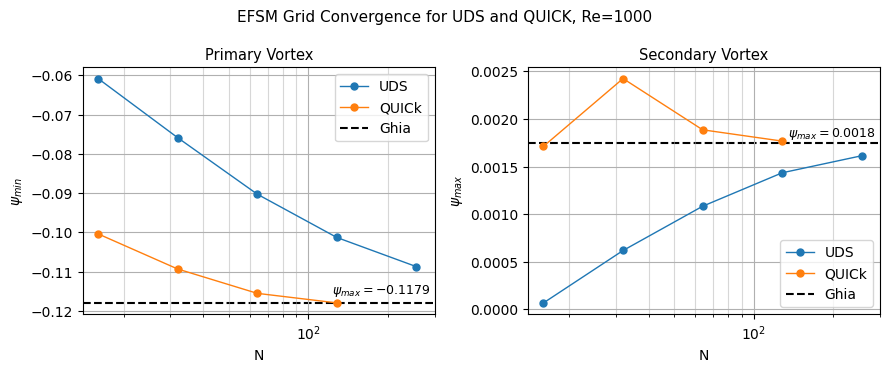

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.75))
uds_primary = manager.collect_vortex_strengths()
labels = ["UDS","QUICk", "SIMPLE UDS"]
groups=[manager, manager2]
for group,label in zip(groups, labels):
    primary, secondary = group.collect_vortex_strengths()
    psi_min = primary["psi"]
    psi_max = secondary["psi"]
    ms,lw =5, 1
    axes[0].plot(primary["N"],primary["psi"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
    axes[1].plot(secondary["N"], secondary["psi"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)

ghia = [-0.117929, 0.00175102]
for ax, title, y_label,ref_psi in zip(axes, ["Primary Vortex", "Secondary Vortex"], [r"$\psi_{min}$", r"$\psi_{max}$"], ghia):
     ax.set_title(title, fontsize=10.5)      
     ax.set_xlabel("N")
     ax.grid(which='major')
     ax.grid(which='minor', alpha=0.5)
     ax.set_ylabel(y_label)
     ax.axhline(y=ref_psi, color='black', linestyle='--', label='Ghia',zorder=0)
     ax.annotate(rf'$\psi_{{max}}={ref_psi:.4f}$', 
                    xy=(290, ref_psi+0.01*abs(ref_psi)), ha='right', va='bottom',
                    fontsize=9,
                    color='black')
     ax.set_xscale('log')
     ax.set_xlim(14, 300)
     ax.legend()

fig.suptitle("Re=1000, EFSM Grid Convergence", fontsize=11)
fig.tight_layout()
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend( handles,labels,ncol=4, loc='upper center', bbox_to_anchor=(0.5, 0))

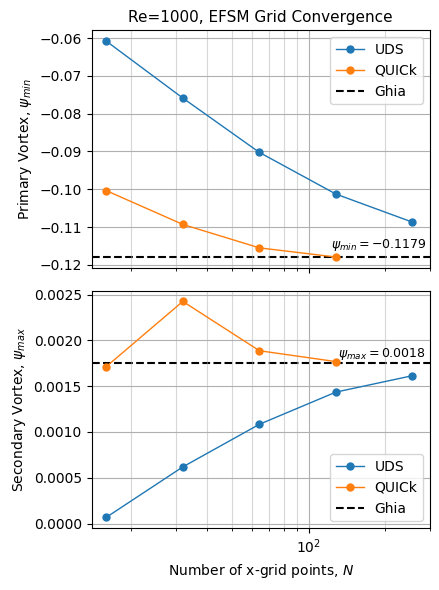

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(4.5, 6), sharex=True)
uds_primary = manager.collect_vortex_strengths()
labels = ["UDS","QUICk", "SIMPLE UDS"]
groups=[manager, manager2]
for group,label in zip(groups, labels):
    primary, secondary = group.collect_vortex_strengths()
    psi_min = primary["psi"]
    psi_max = secondary["psi"]
    ms,lw =5, 1
    axes[0].plot(primary["N"],primary["psi"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
    axes[1].plot(secondary["N"], secondary["psi"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)

ghia = [-0.117929, 0.00175102]
for ax, title, y_label,ref_psi in zip(axes, ["Primary Vortex", "Secondary Vortex"], [r"$\psi_{min}$", r"$\psi_{max}$"], ghia):
    #  ax.set_title(title, fontsize=10.5)      
     ax.grid(which='major')
     ax.grid(which='minor', alpha=0.5)
     ax.set_ylabel(title+', '+y_label)
     ax.axhline(y=ref_psi, color='black', linestyle='--', label='Ghia',zorder=0)
     ax.annotate(rf'{y_label}$={ref_psi:.4f}$', 
                    xy=(290, ref_psi+0.01*abs(ref_psi)), ha='right', va='bottom',
                    fontsize=9,
                    color='black')
     ax.set_xscale('log')
     ax.set_xlim(14, 300)
     ax.legend()
axes[1].set_xlabel(r"Number of x-grid points, $N$")
axes[0].set_title("Re=1000, EFSM Grid Convergence", fontsize=11)
fig.tight_layout()
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend( handles,labels,ncol=4, loc='upper center', bbox_to_anchor=(0.5, 0))